In [ ]:
import cv2
from google.colab.patches import cv2_imshow
import numpy as np

# Initialize video
cap = cv2.VideoCapture('/content/Trimmed.mp4')
fps = cap.get(cv2.CAP_PROP_FPS)


SCALE = 0.008

prev_center = None
prev_velocity_x = 0
prev_velocity_y = 0
timer = 0
time = 1/fps

movement = [[0,0,0,0,0]]

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # 1. Convert to HSV
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # 2. Threshold for Red Color
    lower_red1 = np.array([0, 50, 70])
    upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([170, 50, 70])
    upper_red2 = np.array([180, 255, 255])

    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
    mask = mask1 + mask2

    # Clean up noise
    mask = cv2.erode(mask, None, iterations=2)
    mask = cv2.dilate(mask, None, iterations=2)

    # 3. Find Contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)


    if contours:
        c = max(contours, key=cv2.contourArea)
        M = cv2.moments(c)

        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            center = (cx, cy)
            timer += 1

            # 4. Calculate Physics (Directional)
            if prev_center is not None:

                # (prev - curr) gives Positive for LEFT, Negative for RIGHT
                dx_pixels = prev_center[0] - cx
                dy_pixels = prev_center[1] - cy

                # Convert to meters
                dx_meters = dx_pixels * SCALE
                dy_meters = dy_pixels * SCALE

                # Velocity
                velocity_x = dx_meters * fps
                velocity_y = dy_meters * fps


                # Accekeration
                acceleration_x = (velocity_x - prev_velocity_x) * fps
                acceleration_y = (velocity_y - prev_velocity_y) * fps

                # Update previous for next loop
                prev_velocity_x = velocity_x
                prev_velocity_y = velocity_y

                movement.append([timer * time, -velocity_x, -velocity_y, acceleration_x, acceleration_y])

                # Visualization
                # We use specific formatting to show the negative sign clearly
                cv2.putText(frame, f"Vel X: {velocity_x:+.2f} m/s", (10, 50),
                            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
                cv2.putText(frame, f"Vel Y: {velocity_y:+.2f} m/s", (10, 90),
                            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
                cv2.putText(frame, f"Acc X: {acceleration_x:+.2f} m/s^2", (10, 130),
                            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
                cv2.putText(frame, f"Acc Y: {acceleration_y:+.2f} m/s^2", (10, 170),
                            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

            prev_center = center

            # Draw tracking dot
            cv2.circle(frame, center, 5, (255, 0, 0), -1)

    cv2_imshow(frame)


movement = np.array(movement)
print(movement)
cap.release()

In [ ]:
process_video_with_auto_track('/content/robot-soccer-penalty-kick-video_kWJsw1mX.mp4', 'output.mp4', movement, scale_factor = 125)

Robot detected at start position: (710, 358)
Finished. Saved to output.mp4


In [ ]:
import cv2
import numpy as np

def get_red_robot_start_pos(frame):
    """
    Detects the largest red object in the frame and returns its (x, y) center.
    """
    # 1. Convert to HSV color space
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # 2. Define Red Color Ranges (Red wraps around 0 and 180 in OpenCV)
    # Lower Red range (Hue 0-10)
    lower_red1 = np.array([0, 50, 70])
    upper_red1 = np.array([10, 255, 255])

    # Upper Red range (Hue 170-180)
    lower_red2 = np.array([170, 50, 70])
    upper_red2 = np.array([180, 255, 255])

    # 3. Create Masks and Combine
    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
    mask = mask1 + mask2  # Combine boolean masks

    # Optional: Clean noise with morphology (remove small dots)
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    # 4. Find Contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        print("Warning: No red object detected in the first frame.")
        return None

    # 5. Find the largest contour by area
    largest_contour = max(contours, key=cv2.contourArea)

    # Get bounding box coordinates for the center
    x, y, w, h = cv2.boundingRect(largest_contour)
    center_x = int(x + w / 2)
    center_y = int(y + h / 2)

    return (center_x, center_y)

def process_video_with_auto_track(input_video_path, output_video_path, kinematic_data, scale_factor=10.0):
    cap = cv2.VideoCapture(input_video_path)
    if not cap.isOpened():
        print("Error: Could not open video.")
        return

    # --- AUTO-DETECT START POS ---
    ret, first_frame = cap.read()
    if not ret:
        print("Error: Video is empty.")
        return

    start_pos = get_red_robot_start_pos(first_frame)

    if start_pos is None:
        # Fallback if detection fails
        start_pos = (int(first_frame.shape[1]/2), int(first_frame.shape[0]/2))
        print(f"Using center fallback: {start_pos}")
    else:
        print(f"Robot detected at start position: {start_pos}")

    # Reset video to the beginning so we don't miss the first frame in the loop
    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
    # -----------------------------

    # Video Properties
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = cap.get(cv2.CAP_PROP_FPS)

    # Change the extension to .webm and use the VP8 codec
    # fourcc = cv2.VideoWriter_fourcc(*'VP80')
    # out = cv2.VideoWriter(output_video_path.replace('.mp4', '.webm'), fourcc, fps, (width, height))
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out    = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    # Calculate Physics Positions
    # Assumes data corresponds to frames (1-to-1). Interpolate if necessary.
    dt = np.diff(kinematic_data[:, 0], prepend=0)
    vx = kinematic_data[:, 1]
    vy = kinematic_data[:, 2]

    # Integrate velocity to get displacement
    dx = vx * dt
    dy = vy * dt

    # Cumulative sum creates the path relative to (0,0)
    path_x = np.cumsum(dx)
    path_y = np.cumsum(dy)

    # Add the detected start position to the path
    pixel_path_x = start_pos[0] + (path_x * scale_factor)
    pixel_path_y = start_pos[1] + (path_y * scale_factor)

    frame_idx = 0
    max_frames = kinematic_data.shape[0]

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx < max_frames:
            # Draw the box
            cx = int(pixel_path_x[frame_idx])
            cy = int(pixel_path_y[frame_idx])

            # Draw overlay
            box_size = 60
            top_left = (cx - box_size//2, cy - box_size//2)
            btm_right = (cx + box_size//2, cy + box_size//2)

            # Draw a blue box to distinguish from the red robot
            cv2.rectangle(frame, top_left, btm_right, (255, 0, 0), 3)
            cv2.putText(frame, "Calculated Pos", (top_left[0], top_left[1]-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

        out.write(frame)
        frame_idx += 1

    cap.release()
    out.release()
    print(f"Finished. Saved to {output_video_path}")

In [ ]:
import matplotlib.pyplot as plt

# 1. Unpack the data from your 'movement' array
# Column 0: Time, 1: Vel X, 2: Vel Y, 3: Acc X, 4: Acc Y
time_data = movement[:-1, 0]
vel_x     = movement[:-1, 1]
vel_y     = movement[:-1, 2]
acc_x     = movement[:-1, 3]
acc_y     = movement[:-1, 4]

# 2. Create a figure with two subplots (stacked vertically)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# --- Plot 1: Velocity ---
ax1.plot(time_data, vel_x, label='Velocity X', color='blue', linewidth=2)
ax1.plot(time_data, vel_y, label='Velocity Y', color='orange', linewidth=2)
ax1.set_ylabel('Speed (m/s)', fontsize=12)
ax1.set_title('Extracted Velocity Profile', fontsize=14)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.6)

# --- Plot 2: Acceleration ---
ax2.plot(time_data, acc_x, label='Acceleration X', color='green', linewidth=2)
ax2.plot(time_data, acc_y, label='Acceleration Y', color='red', linewidth=2)
ax2.set_xlabel('Time (seconds)', fontsize=12)
ax2.set_ylabel('Acceleration (m/s²)', fontsize=12)
ax2.set_title('Extracted Acceleration Profile', fontsize=14)
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.6)

# 3. Save the plot for your PowerPoint
plt.tight_layout()
plt.savefig('robot_movement_plot.png', dpi=300)
plt.show()

In [ ]:
import numpy as np
from scipy.signal import savgol_filter

def get_final_kinematic_plan(vx_raw, vy_raw, fps=24.0):
    # Stage 1: Pre-Conditioning (10-frame Zero Anchor)
    vx_anchored = np.concatenate([np.zeros(10), vx_raw])
    vy_anchored = np.concatenate([np.zeros(10), vy_raw])

    # Stage 2: Savitzky-Golay Filter (Window 25, Poly-Order 3)
    # This preserves the peak speed and distance (99.8%) better than Moving Avg
    win = 25
    vx_smooth = savgol_filter(vx_anchored, win, 3)
    vy_smooth = savgol_filter(vy_anchored, win, 3)

    # Stage 3: Post-Processing (Hard Stop)
    # This fixes the start/end drift revealed in the inspection plots
    vx_smooth[:5] = 0;
    vy_smooth[:5] = 0;

    # Calculate Acceleration Profiles
    dt = 1.0 / fps
    ax_smooth = np.gradient(vx_smooth, dt)
    ay_smooth = np.gradient(vy_smooth, dt)

    time = np.linspace(0, (len(vx_smooth)-1)*dt, len(vx_smooth))

    # Bundle into kinematic_data for your visualizer function
    kinematic_data = np.column_stack((time, vx_smooth, vy_smooth))

    return kinematic_data, ax_smooth, ay_smooth

In [ ]:
import matplotlib.pyplot as plt

time_data = movement[:, 0]
vel_x     = movement[:, 1]
vel_y     = movement[:, 2]
acc_x     = movement[:, 3]
acc_y     = movement[:, 4]

# Generate the data
kin_data, acc_x, acc_y = get_final_kinematic_plan(vel_x, vel_y) # Use your raw v_x, v_y
time = kin_data[:, 0]
vx = kin_data[:, 1]
vy = kin_data[:, 2]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot 1: Velocity Profile
ax1.plot(time, vx, color='blue', label='Velocity X', linewidth=2)
ax1.plot(time, vy, color='orange', label='Velocity Y', linewidth=2)
ax1.set_title("Filtered Velocity Profile (Savitzky-Golay)", fontsize=14)
ax1.set_ylabel("Speed (m/s)", fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Acceleration Profile
ax2.plot(time, acc_x, color='green', label='Acceleration X', linewidth=2)
ax2.plot(time, acc_y, color='red', label='Acceleration Y', linewidth=2)
ax2.set_title("Resulting Acceleration Profile", fontsize=14)
ax2.set_ylabel("Acceleration (m/s²)", fontsize=12)
ax2.set_xlabel("Time (seconds)", fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
process_video_with_auto_track(
    input_video_path='/content/robot-soccer-penalty-kick-video_kWJsw1mX.mp4',
    output_video_path='test_result.mp4',
    kinematic_data=kin_data,
    scale_factor=125
)

# from IPython.display import HTML
# from base64 import b64encode

# def display_webm(path):
#     # Ensure we are looking for the .webm version
#     webm_path = path.replace('.mp4', '.webm')
#     video_file = open(webm_path, "rb").read()
#     video_url = f"data:video/webm;base64,{b64encode(video_file).decode()}"
#     return HTML(f"""
#     <video width="800" controls>
#           <source src="{video_url}" type="video/webm">
#     </video>
#     """)

# # Call this after your processing is done
# display_webm('/content/test_result.webm')

Robot detected at start position: (710, 358)
Finished. Saved to test_result.mp4


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Define Smoothing Function ---
def smooth_data(data, window_size=5):
    kernel = np.ones(window_size) / window_size
    return np.convolve(data, kernel, mode='same')

# --- 2. Extract and Smooth Velocity First ---
time_data = movement[:, 0]

# Smooth the velocity (Window size 10 is good for stability)
vel_x_smooth = smooth_data(movement[:, 1], window_size=10)
vel_y_smooth = smooth_data(movement[:, 2], window_size=10)

# --- 3. Derive Acceleration from Smoothed Velocity ---
# We use np.gradient to calculate the derivative (dv/dt)
# Since data is per-frame, we multiply by fps to get units per second^2
# fps was defined in your earlier code (e.g., 30 or 60)

acc_x_new = np.gradient(vel_x_smooth) * fps
acc_y_new = np.gradient(vel_y_smooth) * fps

# Optional: You can apply a tiny smooth to this new acceleration if it's still jagged
acc_x_new = smooth_data(acc_x_new, window_size=3)
acc_y_new = smooth_data(acc_y_new, window_size=3)

# --- 4. Plotting ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Velocity Plot
ax1.plot(time_data, vel_x_smooth, label='Velocity X (Smoothed)', color='blue', linewidth=2)
ax1.plot(time_data, vel_y_smooth, label='Velocity Y (Smoothed)', color='orange', linewidth=2)
ax1.set_ylabel('Speed (m/s)', fontsize=12)
ax1.set_title('Extracted Velocity Profile', fontsize=14)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.6)

# Acceleration Plot (Derived)
ax2.plot(time_data, acc_x_new, label='Acceleration X (Derived)', color='green', linewidth=2)
ax2.plot(time_data, acc_y_new, label='Acceleration Y (Derived)', color='red', linewidth=2)
ax2.set_xlabel('Time (seconds)', fontsize=12)
ax2.set_ylabel('Acceleration (m/s²)', fontsize=12)
ax2.set_title('Acceleration Derived from Smoothed Velocity', fontsize=14)
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('robot_movement_derived_physics.png', dpi=300)
plt.show()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Define the Kalman Filter Function ---
def run_kalman_filter(noisy_velocity, fps):
    """
    Applies a Kalman Filter to estimate Velocity and Acceleration.
    State: [velocity, acceleration]
    Measurement: [velocity]
    """
    dt = 1.0 / fps
    n_steps = len(noisy_velocity)

    # Initialize OpenCV Kalman Filter
    # 2 dynamic parameters (Vel, Acc), 1 measurement parameter (Vel), 0 control
    kf = cv2.KalmanFilter(2, 1, 0)

    # Transition Matrix (F) - The Physics Model
    # v_new = v_old + a_old * dt
    # a_new = a_old
    kf.transitionMatrix = np.array([[1, dt],
                                    [0, 1]], np.float32)

    # Measurement Matrix (H) - We only measure Velocity
    kf.measurementMatrix = np.array([[1, 0]], np.float32)

    # --- Tuning for Responsiveness ---

# Increase Q: Tells the filter the robot CAN change acceleration/velocity quickly.
    kf.processNoiseCov = np.array([[1e-2, 0],   # Velocity noise
                                    [0, 1e-1]], np.float32) # Acceleration noise

    # Decrease R: Tells the filter to trust the raw video data more.
    # Lowering this from 10 to 1 will make it "snap" to zero faster.
    kf.measurementNoiseCov = np.array([[1.0]], np.float32)

    # Initial State
    kf.statePost = np.array([[noisy_velocity[0]], [0]], np.float32)

    # Storage for results
    smooth_vel = []
    smooth_acc = []

    for z in noisy_velocity:
        # 1. Measurement Update (Correct)
        measurement = np.array([[np.float32(z)]])
        kf.correct(measurement)

        # 2. Prediction (Predict next state)
        prediction = kf.predict()

        # Store the "Corrected" state (best estimate of current reality)
        # statePost[0] is Velocity, statePost[1] is Acceleration
        smooth_vel.append(kf.statePost[0, 0])
        smooth_acc.append(kf.statePost[1, 0])

    return np.array(smooth_vel), np.array(smooth_acc)

In [ ]:
# --- 2. Run the Filter on X and Y Data ---
# Note: Ensure 'movement' and 'fps' are defined from your extraction code
time_data = movement[:, 0]
raw_vel_x = movement[:, 1]
raw_vel_y = movement[:, 2]

# Zero-Padding: Add 10 frames of 0 velocity to the end of your raw data
# This gives the Kalman filter time to 'decay' back to zero.
raw_vel_x_padded = np.append(raw_vel_x, [0]*10)
raw_vel_y_padded = np.append(raw_vel_y, [0]*10)

# Re-run the filter on the padded data
# kf_vel_x, kf_acc_x = run_kalman_filter(raw_vel_x_padded, fps)

# Run Kalman Filter
kf_vel_x, kf_acc_x = run_kalman_filter(raw_vel_x_padded, fps)
kf_vel_y, kf_acc_y = run_kalman_filter(raw_vel_y_padded, fps)
print(fps)
# --- 3. Plotting ---
# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

dt = 1.0 / fps
extra_time = np.linspace(time_data[-1] + dt, time_data[-1] + (10 * dt), 10)
time_data_padded = np.append(time_data, extra_time)

# 4. Now Plot using 'time_data_padded'
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Velocity Plot
ax1.plot(time_data_padded, raw_vel_x_padded, label='Raw Input (Noisy)', color='lightgray', alpha=0.5)
ax1.plot(time_data_padded, kf_vel_x, label='Kalman Velocity X', color='blue', linewidth=2)
ax1.plot(time_data_padded, kf_vel_y, label='Kalman Velocity Y', color='orange', linewidth=2)
ax1.set_ylabel('Speed (m/s)', fontsize=12)
ax1.set_title('Kalman Filtered Velocity', fontsize=14)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.6)

# Acceleration Plot
ax2.plot(time_data_padded, kf_acc_x, label='Kalman Accel X', color='green', linewidth=2)
ax2.plot(time_data_padded, kf_acc_y, label='Kalman Accel Y', color='red', linewidth=2)
ax2.set_xlabel('Time (seconds)', fontsize=12)
ax2.set_ylabel('Acceleration (m/s²)', fontsize=12)
ax2.set_title('Kalman Filtered Acceleration', fontsize=14)
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('robot_kalman_physics.png', dpi=300)
plt.show()

In [ ]:
process_video_with_auto_track('/content/Trimmed.mp4', 'New_output.mp4', movement, scale_factor = 125)

Robot detected at start position: (709, 358)
Finished. Saved to New_output.mp4


In [ ]:
from IPython.core.interactiveshell import dis
import cv2
from google.colab.patches import cv2_imshow
import numpy as np

# Initialize video
cap = cv2.VideoCapture('/content/Adobe Express - Robot_Navigates_White_Maze.mp4')
fps = cap.get(cv2.CAP_PROP_FPS)


SCALE = 0.008

prev_center = None
prev_velocity_x = 0
prev_velocity_y = 0
timer = 0
time = 1/fps
distance_x = 0
distance_y = 0
turn_x = []
turn_y = []
turning = False

movement = [[0,0,0,0,0]]

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # 1. Convert to HSV
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # 2. Threshold for Red Color
    lower_red1 = np.array([0, 50, 70])
    upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([170, 50, 70])
    upper_red2 = np.array([180, 255, 255])

    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
    mask = mask1 + mask2

    # Clean up noise
    mask = cv2.erode(mask, None, iterations=2)
    mask = cv2.dilate(mask, None, iterations=2)

    # 3. Find Contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)


    if contours:
        c = max(contours, key=cv2.contourArea)
        M = cv2.moments(c)

        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            center = (cx, cy)
            timer += 1

            # 4. Calculate Physics (Directional)
            if prev_center is not None:

                # (prev - curr) gives Positive for LEFT, Negative for RIGHT
                dx_pixels = prev_center[0] - cx
                dy_pixels = prev_center[1] - cy

                # Convert to meters
                dx_meters = dx_pixels * SCALE
                dy_meters = dy_pixels * SCALE

                distance_x += np.abs(dx_meters)
                distance_y += np.abs(dy_meters)

                # Velocity
                velocity_x = -dx_meters * fps
                velocity_y = dy_meters * fps


                # Accekeration
                acceleration_x = (velocity_x - prev_velocity_x) * fps
                acceleration_y = (velocity_y - prev_velocity_y) * fps

                # if np.abs(velocity_x - velocity_y) < 0.4:
                #   if np.abs(velocity_x) <np.abs(velocity_y):
                #     turn_y.append([distance_x,np.sign(velocity_y)])
                #     cv2.putText(frame, f"Turn in ({np.sign(velocity_y)})Y direction", (10, 210),
                #             cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
                #     distance_x = 0
                #     distance_y = 0
                #   else:
                #     turn_x.append([distance_y,np.sign(velocity_x)])
                #     cv2.putText(frame, f"Turn to ({np.sign(velocity_x)})X direction", (10, 210),
                #             cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
                #     distance_x = 0
                #     distance_y = 0


                # Update previous for next loop
                prev_velocity_x = velocity_x
                prev_velocity_y = velocity_y



                movement.append([timer * time, velocity_x, -velocity_y, acceleration_x, acceleration_y])

                # Visualization
                # We use specific formatting to show the negative sign clearly
                cv2.putText(frame, f"Vel X: {velocity_x:+.2f} m/s", (10, 50),
                            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
                cv2.putText(frame, f"Vel Y: {velocity_y:+.2f} m/s", (10, 90),
                            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
                cv2.putText(frame, f"Acc X: {acceleration_x:+.2f} m/s^2", (10, 130),
                            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
                cv2.putText(frame, f"Acc Y: {acceleration_y:+.2f} m/s^2", (10, 170),
                            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

            prev_center = center

            # Draw tracking dot
            cv2.circle(frame, center, 5, (255, 0, 0), -1)

    cv2_imshow(frame)

    # if cv2.waitKey(30) & 0xFF == ord('q'):
    #     break
movement = np.array(movement)
print(movement)
turn_x = np.array(turn_x)
turn_y = np.array(turn_y)
cap.release()
# cv2.destroyAllWindows()

In [ ]:
process_video_with_auto_track('/content/Robot_Navigates_White_Maze.mp4', 'output.mp4', movement, scale_factor = 125)

Robot detected at start position: (588, 265)
Finished. Saved to output.mp4


In [ ]:
import matplotlib.pyplot as plt

# 1. Unpack the data from your 'movement' array
# Column 0: Time, 1: Vel X, 2: Vel Y, 3: Acc X, 4: Acc Y
time_data = movement[:, 0]
vel_x     = movement[:, 1]
vel_y     = movement[:, 2]
acc_x     = movement[:, 3]
acc_y     = movement[:, 4]

# 2. Create a figure with two subplots (stacked vertically)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# --- Plot 1: Velocity ---
ax1.plot(time_data, vel_x, label='Velocity X', color='blue', linewidth=2)
ax1.plot(time_data, vel_y, label='Velocity Y', color='orange', linewidth=2)
ax1.set_ylabel('Speed (m/s)', fontsize=12)
ax1.set_title('Extracted Velocity Profile', fontsize=14)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.6)

# --- Plot 2: Acceleration ---
ax2.plot(time_data, acc_x, label='Acceleration X', color='green', linewidth=2)
ax2.plot(time_data, acc_y, label='Acceleration Y', color='red', linewidth=2)
ax2.set_xlabel('Time (seconds)', fontsize=12)
ax2.set_ylabel('Acceleration (m/s²)', fontsize=12)
ax2.set_title('Extracted Acceleration Profile', fontsize=14)
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.6)

# 3. Save the plot for your PowerPoint
plt.tight_layout()
plt.savefig('robot_movement_plot.png', dpi=300)
plt.show()

In [ ]:
import numpy as np
from scipy.signal import savgol_filter

def get_final_kinematic_plan(vx_raw, vy_raw, fps=24.0):
    # Stage 1: Pre-Conditioning (10-frame Zero Anchor)
    vx_anchored = np.concatenate([np.zeros(10), vx_raw])
    vy_anchored = np.concatenate([np.zeros(10), vy_raw])

    # Stage 2: Savitzky-Golay Filter (Window 25, Poly-Order 3)
    # This preserves the peak speed and distance (99.8%) better than Moving Avg
    win = 25
    vx_smooth = savgol_filter(vx_anchored, win, 3)
    vy_smooth = savgol_filter(vy_anchored, win, 3)

    # Stage 3: Post-Processing (Hard Stop)
    # This fixes the start/end drift revealed in the inspection plots
    vx_smooth[:5] = 0; vx_smooth[-5:] = 0
    vy_smooth[:5] = 0; vy_smooth[-5:] = 0

    # Calculate Acceleration Profiles
    dt = 1.0 / fps
    ax_smooth = np.gradient(vx_smooth, dt)
    ay_smooth = np.gradient(vy_smooth, dt)

    time = np.linspace(0, (len(vx_smooth)-1)*dt, len(vx_smooth))

    # Bundle into kinematic_data for your visualizer function
    kinematic_data = np.column_stack((time, vx_smooth, vy_smooth))

    return kinematic_data, ax_smooth, ay_smooth

In [ ]:
import matplotlib.pyplot as plt

time_data = movement[:, 0]
vel_x     = movement[:, 1]
vel_y     = movement[:, 2]
acc_x     = movement[:, 3]
acc_y     = movement[:, 4]

# Generate the data
kin_data, acc_x, acc_y = get_final_kinematic_plan(vel_x, vel_y) # Use your raw v_x, v_y
time = kin_data[:, 0]
vx = kin_data[:, 1]
vy = kin_data[:, 2]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot 1: Velocity Profile
ax1.plot(time, vx, color='blue', label='Velocity X', linewidth=2)
ax1.plot(time, vy, color='orange', label='Velocity Y', linewidth=2)
ax1.set_title("Filtered Velocity Profile (Savitzky-Golay)", fontsize=14)
ax1.set_ylabel("Speed (m/s)", fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Acceleration Profile
ax2.plot(time, acc_x, color='green', label='Acceleration X', linewidth=2)
ax2.plot(time, acc_y, color='red', label='Acceleration Y', linewidth=2)
ax2.set_title("Resulting Acceleration Profile", fontsize=14)
ax2.set_ylabel("Acceleration (m/s²)", fontsize=12)
ax2.set_xlabel("Time (seconds)", fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
process_video_with_auto_track(
    input_video_path='/content/Robot_Navigates_White_Maze.mp4',
    output_video_path='test_result.mp4',
    kinematic_data=kin_data,
    scale_factor=125
)

# from IPython.display import HTML
# from base64 import b64encode

# def display_webm(path):
#     # Ensure we are looking for the .webm version
#     webm_path = path.replace('.mp4', '.webm')
#     video_file = open(webm_path, "rb").read()
#     video_url = f"data:video/webm;base64,{b64encode(video_file).decode()}"
#     return HTML(f"""
#     <video width="800" controls>
#           <source src="{video_url}" type="video/webm">
#     </video>
#     """)

# # Call this after your processing is done
# display_webm('/content/test_result.webm')

Robot detected at start position: (588, 265)
Finished. Saved to test_result.mp4


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Define Smoothing Function ---
def smooth_data(data, window_size=5):
    kernel = np.ones(window_size) / window_size
    return np.convolve(data, kernel, mode='same')

# --- 2. Extract and Smooth Velocity First ---
time_data = movement[:, 0]

# Smooth the velocity (Window size 10 is good for stability)
vel_x_smooth = smooth_data(movement[:, 1], window_size=20)
vel_y_smooth = smooth_data(movement[:, 2], window_size=20)

# --- 3. Derive Acceleration from Smoothed Velocity ---
# We use np.gradient to calculate the derivative (dv/dt)
# Since data is per-frame, we multiply by fps to get units per second^2
# fps was defined in your earlier code (e.g., 30 or 60)

acc_x_new = np.gradient(vel_x_smooth) * fps
acc_y_new = np.gradient(vel_y_smooth) * fps

# Optional: You can apply a tiny smooth to this new acceleration if it's still jagged
acc_x_new = smooth_data(acc_x_new, window_size=10)
acc_y_new = smooth_data(acc_y_new, window_size=10)

# --- 4. Plotting ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Velocity Plot
ax1.plot(time_data, vel_x_smooth, label='Velocity X (Smoothed)', color='blue', linewidth=2)
ax1.plot(time_data, vel_y_smooth, label='Velocity Y (Smoothed)', color='orange', linewidth=2)
ax1.set_ylabel('Speed (m/s)', fontsize=12)
ax1.set_title('Extracted Velocity Profile', fontsize=14)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.6)

# Acceleration Plot (Derived)
ax2.plot(time_data, acc_x_new, label='Acceleration X (Derived)', color='green', linewidth=2)
ax2.plot(time_data, acc_y_new, label='Acceleration Y (Derived)', color='red', linewidth=2)
ax2.set_xlabel('Time (seconds)', fontsize=12)
ax2.set_ylabel('Acceleration (m/s²)', fontsize=12)
ax2.set_title('Acceleration Derived from Smoothed Velocity', fontsize=14)
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('robot_movement_derived_physics.png', dpi=300)
plt.show()

In [ ]:
time_col = np.linspace(0, (len(vel_x_smooth) - 1) / fps, len(vel_x_smooth))
my = np.column_stack((time_col, vel_x_smooth, vel_y_smooth))

process_video_with_auto_track(
    input_video_path='/content/Robot_Navigates_White_Maze.mp4',
    output_video_path='test_result.mp4',
    kinematic_data=my,
    scale_factor=125
)

from IPython.display import HTML
from base64 import b64encode

def display_webm(path):
    # Ensure we are looking for the .webm version
    webm_path = path.replace('.mp4', '.webm')
    video_file = open(webm_path, "rb").read()
    video_url = f"data:video/webm;base64,{b64encode(video_file).decode()}"
    return HTML(f"""
    <video width="800" controls>
          <source src="{video_url}" type="video/webm">
    </video>
    """)

# Call this after your processing is done
display_webm('/content/test_result.webm')

In [ ]:
# --- 2. Run the Filter on X and Y Data ---
# Note: Ensure 'movement' and 'fps' are defined from your extraction code
time_data = movement[:, 0]
raw_vel_x = movement[:, 1]
raw_vel_y = movement[:, 2]

# Run Kalman Filter
kf_vel_x, kf_acc_x = run_kalman_filter(raw_vel_x, fps)
kf_vel_y, kf_acc_y = run_kalman_filter(raw_vel_y, fps)

kf_vel_bwd_flipped, kf_acc_bwd_flipped = run_kalman_filter(raw_vel_x[::-1], fps)
kf_vel_bwd = kf_vel_bwd_flipped[::-1]

# 3. Average the results for a zero-lag estimate
# final_vel_x = (kf_vel_fwd + kf_vel_bwd) / 2

# --- 3. Plotting ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Velocity Plot
ax1.plot(time_data, raw_vel_x, label='Raw Input (Noisy)', color='lightgray', alpha=0.5)
ax1.plot(time_data, kf_vel_x, label='Kalman Velocity X', color='blue', linewidth=2)
ax1.plot(time_data, kf_vel_y, label='Kalman Velocity Y', color='orange', linewidth=2)
ax1.set_ylabel('Speed (m/s)', fontsize=12)
ax1.set_title('Kalman Filtered Velocity', fontsize=14)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.6)

# Acceleration Plot
ax2.plot(time_data, kf_acc_x, label='Kalman Accel X', color='green', linewidth=2)
ax2.plot(time_data, kf_acc_y, label='Kalman Accel Y', color='red', linewidth=2)
ax2.set_xlabel('Time (seconds)', fontsize=12)
ax2.set_ylabel('Acceleration (m/s²)', fontsize=12)
ax2.set_title('Kalman Filtered Acceleration', fontsize=14)
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('robot_kalman_physics.png', dpi=300)
plt.show()

In [ ]:
# --- 2. Run the Filter on X and Y Data ---
# Note: Ensure 'movement' and 'fps' are defined from your extraction code
time_data = movement[:, 0]
raw_vel_x = movement[:, 1]
raw_vel_y = movement[:, 2]

# Zero-Padding: Add 10 frames of 0 velocity to the end of your raw data
# This gives the Kalman filter time to 'decay' back to zero.
raw_vel_x_padded = np.append(raw_vel_x, [0]*10)
raw_vel_y_padded = np.append(raw_vel_y, [0]*10)

# Re-run the filter on the padded data
# kf_vel_x, kf_acc_x = run_kalman_filter(raw_vel_x_padded, fps)

# Run Kalman Filter
kf_vel_x, kf_acc_x = run_kalman_filter(raw_vel_x_padded, fps)
kf_vel_y, kf_acc_y = run_kalman_filter(raw_vel_y_padded, fps)
print(fps)
# --- 3. Plotting ---
# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

dt = 1.0 / fps
extra_time = np.linspace(time_data[-1] + dt, time_data[-1] + (10 * dt), 10)
time_data_padded = np.append(time_data, extra_time)

# 4. Now Plot using 'time_data_padded'
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Velocity Plot
ax1.plot(time_data_padded, raw_vel_x_padded, label='Raw Input (Noisy)', color='lightgray', alpha=0.5)
ax1.plot(time_data_padded, kf_vel_x, label='Kalman Velocity X', color='blue', linewidth=2)
ax1.plot(time_data_padded, kf_vel_y, label='Kalman Velocity Y', color='orange', linewidth=2)
ax1.set_ylabel('Speed (m/s)', fontsize=12)
ax1.set_title('Kalman Filtered Velocity', fontsize=14)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.6)

# Acceleration Plot
ax2.plot(time_data_padded, kf_acc_x, label='Kalman Accel X', color='green', linewidth=2)
ax2.plot(time_data_padded, kf_acc_y, label='Kalman Accel Y', color='red', linewidth=2)
ax2.set_xlabel('Time (seconds)', fontsize=12)
ax2.set_ylabel('Acceleration (m/s²)', fontsize=12)
ax2.set_title('Kalman Filtered Acceleration', fontsize=14)
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('robot_kalman_physics.png', dpi=300)
plt.show()

In [ ]:
time_col = np.linspace(0, (len(kf_vel_x) - 1) / fps, len(kf_vel_x))
my = np.column_stack((time_col, kf_vel_x, kf_vel_y))

process_video_with_auto_track(
    input_video_path='/content/Robot_Navigates_White_Maze.mp4',
    output_video_path='test_result.mp4',
    kinematic_data=my,
    scale_factor=125
)

from IPython.display import HTML
from base64 import b64encode

def display_webm(path):
    # Ensure we are looking for the .webm version
    webm_path = path.replace('.mp4', '.webm')
    video_file = open(webm_path, "rb").read()
    video_url = f"data:video/webm;base64,{b64encode(video_file).decode()}"
    return HTML(f"""
    <video width="800" controls>
          <source src="{video_url}" type="video/webm">
    </video>
    """)

# Call this after your processing is done
display_webm('/content/test_result.webm')

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Bidirectional Kalman Filter Function ---
def run_kalman_filter(noisy_velocity, fps):
    dt = 1.0 / fps
    kf = cv2.KalmanFilter(2, 1, 0)
    kf.transitionMatrix = np.array([[1, dt], [0, 1]], np.float32)
    kf.measurementMatrix = np.array([[1, 0]], np.float32)

    # Tuning for the Robot Goal Task
    kf.processNoiseCov = np.array([[1e-2, 0], [0, 1e-1]], np.float32)
    kf.measurementNoiseCov = np.array([[1.0]], np.float32)
    kf.statePost = np.array([[noisy_velocity[0]], [0]], np.float32)

    smooth_vel = []
    smooth_acc = []

    for z in noisy_velocity:
        kf.correct(np.array([[np.float32(z)]]))
        prediction = kf.predict()
        smooth_vel.append(kf.statePost[0, 0])
        smooth_acc.append(kf.statePost[1, 0])

    return np.array(smooth_vel), np.array(smooth_acc)

# --- 2. Bidirectional Processing (Removes Lag) ---
# Raw data from your earlier extraction
raw_vel_x = movement[:, 1]
raw_vel_y = movement[:, 2]
time_data = movement[:, 0]

# Forward Pass
fwd_vel_x, fwd_acc_x = run_kalman_filter(raw_vel_x, fps)
fwd_vel_y, fwd_acc_y = run_kalman_filter(raw_vel_y, fps)

# Backward Pass (Eliminates the 'tail' at the end)
bwd_vel_x_flip, bwd_acc_x_flip = run_kalman_filter(raw_vel_x[::-1], fps)
bwd_vel_y_flip, bwd_acc_y_flip = run_kalman_filter(raw_vel_y[::-1], fps)

# Combine for Final Zero-Lag Result
final_vel_x = (fwd_vel_x + bwd_vel_x_flip[::-1]) / 2
final_vel_y = (fwd_vel_y + bwd_vel_y_flip[::-1]) / 2
final_acc_x = (fwd_acc_x + bwd_acc_x_flip[::-1]) / 2
final_acc_y = (fwd_acc_y + bwd_acc_y_flip[::-1]) / 2

# --- 3. Plotting for the PowerPoint ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Velocity Plot
ax1.plot(time_data, final_vel_x, label='Velocity X (Final)', color='blue', linewidth=2)
ax1.plot(time_data, final_vel_y, label='Velocity Y (Final)', color='orange', linewidth=2)
ax1.set_ylabel('Speed (m/s)')
ax1.set_title('Zero-Lag Extracted Velocity Profile')
ax1.legend()
ax1.grid(True, linestyle='--')

# Acceleration Plot
ax2.plot(time_data, final_acc_x, label='Accel X', color='green', linewidth=2)
ax2.plot(time_data, final_acc_y, label='Accel Y', color='red', linewidth=2)
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Acceleration (m/s²)')
ax2.set_title('Physically Consistent Acceleration')
ax2.legend()
ax2.grid(True, linestyle='--')

plt.tight_layout()
plt.savefig('task2_final_extraction.png', dpi=300)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Access your raw data (Velocity X and Y from the 'movement' array)
raw_vx = movement[:, 1]
raw_vy = movement[:, 2]
time_data = movement[:, 0]

# 2. Apply a Moving Average (Window of 5-8 frames is usually best for 30fps)
window_size = 7
kernel = np.ones(window_size) / window_size
smooth_vx = np.convolve(raw_vx, kernel, mode='same')
smooth_vy = np.convolve(raw_vy, kernel, mode='same')

# 3. Apply the "Zero-Stop" Threshold
# If velocity is less than 0.1 m/s, it's just noise from the video. Force it to 0.
threshold = 0.1
final_vx = np.where(np.abs(smooth_vx) < threshold, 0, smooth_vx)
final_vy = np.where(np.abs(smooth_vy) < threshold, 0, smooth_vy)

# 4. Re-calculate Acceleration from the CLEAN velocity
# This ensures acceleration also hits zero at the end.
final_ax = np.gradient(final_vx) * fps
final_ay = np.gradient(final_vy) * fps

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(time_data, final_vx, label='Clean Velocity X', color='blue')
ax1.plot(time_data, final_vy, label='Clean Velocity Y', color='orange')
ax1.set_title("Usable Velocity Profile (Filtered)")
ax1.set_ylabel("Speed (m/s)")
ax1.grid(True, alpha=0.3)

ax2.plot(time_data, final_ax, label='Clean Accel X', color='green')
ax2.plot(time_data, final_ay, label='Clean Accel Y', color='red')
ax2.set_title("Usable Acceleration Profile")
ax2.set_xlabel("Time (seconds)")
ax2.set_ylabel("Acceleration (m/s²)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# 1. Access raw data
raw_vx = movement[:, 1]
raw_vy = movement[:, 2]
time_data = movement[:, 0]

# 2. Apply Savitzky-Golay Filter
# window_length: must be odd (e.g., 7, 9, 11). Higher = smoother.
# polyorder: the degree of the polynomial (usually 2 or 3).
window = 11
order = 3

smooth_vx = savgol_filter(raw_vx, window, order)
smooth_vy = savgol_filter(raw_vy, window, order)

# 3. Apply the "Hard Stop" Threshold
# This forces the velocity to 0 when the robot stops at the flag
threshold = 0.12
final_vx = np.where(np.abs(smooth_vx) < threshold, 0, smooth_vx)
final_vy = np.where(np.abs(smooth_vy) < threshold, 0, smooth_vy)

# 4. Derive Acceleration from the Cleaned Velocity
# This ensures a mathematically consistent a = dv/dt
final_ax = np.gradient(final_vx) * fps
final_ay = np.gradient(final_vy) * fps

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(time_data, final_vx, label='S-G Velocity X', color='blue', linewidth=2)
ax1.plot(time_data, final_vy, label='S-G Velocity Y', color='orange', linewidth=2)
ax1.set_title("Savitzky-Golay Filtered Velocity (Optimized)")
ax1.set_ylabel("Speed (m/s)")
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(time_data, final_ax, label='Derived Accel X', color='green', linewidth=2)
ax2.plot(time_data, final_ay, label='Derived Accel Y', color='red', linewidth=2)
ax2.set_title("Physically Consistent Acceleration")
ax2.set_xlabel("Time (seconds)")
ax2.set_ylabel("Acceleration (m/s²)")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def run_kalman(noisy_data, fps):
    dt = 1.0 / fps
    # State: [position, velocity], Measurement: [position]
    kf = cv2.KalmanFilter(2, 1, 0)
    kf.transitionMatrix = np.array([[1, dt], [0, 1]], np.float32)
    kf.measurementMatrix = np.array([[1, 0]], np.float32)

    # Tuning: Lowering MeasurementNoise makes it 'snap' to the data faster
    kf.processNoiseCov = np.array([[1e-4, 0], [0, 1e-3]], np.float32)
    kf.measurementNoiseCov = np.array([[0.1]], np.float32)

    kf.statePost = np.array([[noisy_data[0]], [0]], np.float32)

    estimates = []
    for z in noisy_data:
        kf.correct(np.array([[np.float32(z)]]))
        prediction = kf.predict()
        estimates.append(kf.statePost[1, 0]) # Extract Velocity
    return np.array(estimates)

# --- Processing ---
raw_vx = movement[:, 1]
raw_vy = movement[:, 2]
time_data = movement[:, 0]

# Bidirectional pass to ensure zero-lag and zero-end state
kf_vx = (run_kalman(raw_vx, fps) + run_kalman(raw_vx[::-1], fps)[::-1]) / 2
kf_vy = (run_kalman(raw_vy, fps) + run_kalman(raw_vy[::-1], fps)[::-1]) / 2

# Apply a final noise-floor threshold to guarantee absolute zero
threshold = 0.05
kf_vx = np.where(np.abs(kf_vx) < threshold, 0, kf_vx)
kf_vy = np.where(np.abs(kf_vy) < threshold, 0, kf_vy)

# Derive acceleration
kf_ax = np.gradient(kf_vx) * fps
kf_ay = np.gradient(kf_vy) * fps

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
ax1.plot(time_data, kf_vx, label='Kalman Velocity X', color='blue')
ax1.plot(time_data, kf_vy, label='Kalman Velocity Y', color='orange')
ax1.set_title("Kalman Filter Result (Bidirectional)")
ax1.set_ylabel("Speed (m/s)")
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(time_data, kf_ax, label='Kalman Accel X', color='green')
ax2.plot(time_data, kf_ay, label='Kalman Accel Y', color='red')
ax2.set_xlabel("Time (seconds)")
ax2.set_ylabel("Acceleration (m/s²)")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def run_standard_kalman(noisy_data, fps):
    dt = 1.0 / fps
    # State: [position, velocity], Measurement: [position]
    kf = cv2.KalmanFilter(2, 1, 0)

    # Transition Matrix (Physics: pos = pos + vel*dt)
    kf.transitionMatrix = np.array([[1, dt], [0, 1]], np.float32)

    # Measurement Matrix (We only see position/raw velocity)
    kf.measurementMatrix = np.array([[1, 0]], np.float32)

    # Noise Tuning
    kf.processNoiseCov = np.array([[1e-4, 0], [0, 1e-3]], np.float32)
    kf.measurementNoiseCov = np.array([[0.1]], np.float32)

    # Initial State
    kf.statePost = np.array([[noisy_data[0]], [0]], np.float32)

    estimates = []
    for z in noisy_data:
        kf.correct(np.array([[np.float32(z)]]))
        prediction = kf.predict()
        # We take the 'corrected' velocity
        estimates.append(kf.statePost[1, 0])
    return np.array(estimates)

# --- Process Data ---
raw_vx = movement[:, 1]
raw_vy = movement[:, 2]
time_data = movement[:, 0]

standard_vx = run_standard_kalman(raw_vx, fps)
standard_vy = run_standard_kalman(raw_vy, fps)

# Noise floor for the 'Stop' at the flag
threshold = 0.08
final_vx = np.where(np.abs(standard_vx) < threshold, 0, standard_vx)
final_vy = np.where(np.abs(standard_vy) < threshold, 0, standard_vy)

# Derive Acceleration
final_ax = np.gradient(final_vx) * fps
final_ay = np.gradient(final_vy) * fps

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(time_data, final_vx, label='Standard Kalman Vel X', color='blue')
ax1.plot(time_data, final_vy, label='Standard Kalman Vel Y', color='orange')
ax1.set_title("Standard Forward Kalman Filter (Real-Time Simulation)")
ax1.set_ylabel("Speed (m/s)")
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(time_data, final_ax, label='Standard Kalman Acc X', color='green')
ax2.plot(time_data, final_ay, label='Standard Kalman Acc Y', color='red')
ax2.set_xlabel("Time (seconds)")
ax2.set_ylabel("Acceleration (m/s²)")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# 1. Pre-Filtering Stage (Your Window Size 12 Idea)
window_avg = 12
kernel = np.ones(window_avg) / window_avg
pre_smooth_vx = np.convolve(movement[:, 1], kernel, mode='same')
pre_smooth_vy = np.convolve(movement[:, 2], kernel, mode='same')

# 2. Secondary Refinement Stage (Savitzky-Golay)
# We use a larger window here to force physical "inertia"
final_vx = savgol_filter(pre_smooth_vx, 21, 3)
final_vy = savgol_filter(pre_smooth_vy, 21, 3)

# 3. Apply the "Zero-Stop" Threshold
# Forces velocity to 0 when the robot arrives at the flag
threshold = 0.15
final_vx = np.where(np.abs(final_vx) < threshold, 0, final_vx)
final_vy = np.where(np.abs(final_vy) < threshold, 0, final_vy)

# 4. Derive Acceleration
final_ax = np.gradient(final_vx) * fps
final_ay = np.gradient(final_vy) * fps

# --- Plotting ---
time_data = movement[:, 0]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(time_data, final_vx, label='Cascaded Velocity X', color='blue', linewidth=2.5)
ax1.plot(time_data, final_vy, label='Cascaded Velocity Y', color='orange', linewidth=2.5)
ax1.set_title("Cascaded Filter Result (Averaging + S-G)")
ax1.set_ylabel("Speed (m/s)")
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(time_data, final_ax, label='Cascaded Accel X', color='green', linewidth=2)
ax2.plot(time_data, final_ay, label='Cascaded Accel Y', color='red', linewidth=2)
ax2.set_ylabel("Acceleration (m/s²)")
ax2.set_xlabel("Time (seconds)")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Standard Kalman Logic
def run_kalman(noisy_data, fps):
    dt = 1.0 / fps
    kf = cv2.KalmanFilter(2, 1, 0)
    kf.transitionMatrix = np.array([[1, dt], [0, 1]], np.float32)
    kf.measurementMatrix = np.array([[1, 0]], np.float32)
    kf.processNoiseCov = np.array([[1e-4, 0], [0, 1e-3]], np.float32)
    kf.measurementNoiseCov = np.array([[0.1]], np.float32)
    kf.statePost = np.array([[noisy_data[0]], [0]], np.float32)

    estimates = []
    for z in noisy_data:
        kf.correct(np.array([[np.float32(z)]]))
        prediction = kf.predict()
        estimates.append(kf.statePost[1, 0])
    return np.array(estimates)

# --- Cascaded Processing Stage ---

# 2. Stage 1: Pre-Averaging Filter (Window Size 12)
window_avg = 12
kernel = np.ones(window_avg) / window_avg
pre_avg_vx = np.convolve(movement[:, 1], kernel, mode='same')
pre_avg_vy = np.convolve(movement[:, 2], kernel, mode='same')

# 3. Stage 2: Bidirectional Kalman Filter
# Forward Pass
fwd_vx = run_kalman(pre_avg_vx, fps)
fwd_vy = run_kalman(pre_avg_vy, fps)

# Backward Pass (to eliminate lag)
bwd_vx = run_kalman(pre_avg_vx[::-1], fps)[::-1]
bwd_vy = run_kalman(pre_avg_vy[::-1], fps)[::-1]

# Final Average
final_vx = (fwd_vx + bwd_vx) / 2
final_vy = (fwd_vy + bwd_vy) / 2

# 4. Zero-State Threshold (Ensuring absolute zero at the flag)
threshold = 0.12
final_vx = np.where(np.abs(final_vx) < threshold, 0, final_vx)
final_vy = np.where(np.abs(final_vy) < threshold, 0, final_vy)

# Derive Acceleration
final_ax = np.gradient(final_vx) * fps
final_ay = np.gradient(final_vy) * fps

# --- Plotting ---
time_data = movement[:, 0]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(time_data, final_vx, label='Cascaded Kalman Vel X', color='blue', linewidth=2)
ax1.plot(time_data, final_vy, label='Cascaded Kalman Vel Y', color='orange', linewidth=2)
ax1.set_title("Cascaded Kalman Result (Averaging + Bidirectional KF)")
ax1.set_ylabel("Speed (m/s)")
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(time_data, final_ax, label='Cascaded Accel X', color='green', linewidth=2)
ax2.plot(time_data, final_ay, label='Cascaded Accel Y', color='red', linewidth=2)
ax2.set_xlabel("Time (seconds)")
ax2.set_ylabel("Acceleration (m/s²)")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# 1. Stage 1: Pre-Averaging (Window Size 12)
window_avg = 12
kernel = np.ones(window_avg) / window_avg
pre_avg_vx = np.convolve(movement[:, 1], kernel, mode='same')
pre_avg_vy = np.convolve(movement[:, 2], kernel, mode='same')

# 2. Stage 2: Savitzky-Golay (Refining the curve)
# We use a window of 21 and order 3 for smooth physical transitions
smooth_vx = savgol_filter(pre_avg_vx, 21, 3)
smooth_vy = savgol_filter(pre_avg_vy, 21, 3)

# 3. CRITICAL: Calculate Acceleration BEFORE the threshold
# This prevents the vertical 'spikes' caused by the sudden drop to zero
acc_x_smooth = np.gradient(smooth_vx) * fps
acc_y_smooth = np.gradient(smooth_vy) * fps

# 4. Final Stage: Apply the "Zero-Stop" Threshold to BOTH
# This ensures that when the velocity stops, the acceleration stops too
threshold = 0.15
mask_x = np.abs(smooth_vx) < threshold
mask_y = np.abs(smooth_vy) < threshold

final_vx = np.where(mask_x, 0, smooth_vx)
final_vy = np.where(mask_y, 0, smooth_vy)
final_ax = np.where(mask_x, 0, acc_x_smooth) # Uses the same stop-mask
final_ay = np.where(mask_y, 0, acc_y_smooth)

# --- Plotting ---
time_data = movement[:, 0]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(time_data, final_vx, label='Final Velocity X', color='blue', linewidth=2.5)
ax1.plot(time_data, final_vy, label='Final Velocity Y', color='orange', linewidth=2.5)
ax1.set_title("Optimized Velocity (Cascaded + Threshold)")
ax1.set_ylabel("Speed (m/s)")
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(time_data, final_ax, label='Final Accel X', color='green', linewidth=2)
ax2.plot(time_data, final_ay, label='Final Accel Y', color='red', linewidth=2)
ax2.set_title("Optimized Acceleration (No 'Cliff' Spikes)")
ax2.set_ylabel("Acceleration (m/s²)")
ax2.set_xlabel("Time (seconds)")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def run_kalman_state_estimation(noisy_data, fps):
    dt = 1.0 / fps
    # State: [position, velocity, acceleration]
    # We use 3 dynamic parameters to get a smoother acceleration estimate directly
    kf = cv2.KalmanFilter(3, 1, 0)

    # Transition Matrix (Physics: pos = p + v*dt + 0.5*a*dt^2, vel = v + a*dt, acc = a)
    kf.transitionMatrix = np.array([[1, dt, 0.5*dt**2],
                                    [0, 1, dt],
                                    [0, 0, 1]], np.float32)

    kf.measurementMatrix = np.array([[1, 0, 0]], np.float32)
    kf.processNoiseCov = np.eye(3, dtype=np.float32) * 1e-4
    kf.measurementNoiseCov = np.array([[0.1]], np.float32)
    kf.statePost = np.array([[noisy_data[0]], [0], [0]], np.float32)

    vel_est = []
    acc_est = []

    for z in noisy_data:
        kf.correct(np.array([[np.float32(z)]]))
        prediction = kf.predict()
        vel_est.append(kf.statePost[1, 0])
        acc_est.append(kf.statePost[2, 0])

    return np.array(vel_est), np.array(acc_est)

# --- 1. Stage 1: Pre-Averaging (Window Size 12) ---
window_avg = 12
kernel = np.ones(window_avg) / window_avg
pre_avg_vx = np.convolve(movement[:, 1], kernel, mode='same')
pre_avg_vy = np.convolve(movement[:, 2], kernel, mode='same')

# --- 2. Stage 2: Bidirectional Kalman Estimation ---
# Running forward and backward eliminates the phase lag seen in previous attempts
v_fwd_x, a_fwd_x = run_kalman_state_estimation(pre_avg_vx, fps)
v_bwd_x, a_bwd_x = run_kalman_state_estimation(pre_avg_vx[::-1], fps)
v_fwd_y, a_fwd_y = run_kalman_state_estimation(pre_avg_vy, fps)
v_bwd_y, a_bwd_y = run_kalman_state_estimation(pre_avg_vy[::-1], fps)

# Combine for smooth, zero-lag continuous curves
smooth_vx = (v_fwd_x + v_bwd_x[::-1]) / 2
smooth_ax = (a_fwd_x + a_bwd_x[::-1]) / 2
smooth_vy = (v_fwd_y + v_bwd_y[::-1]) / 2
smooth_ay = (a_fwd_y + a_bwd_y[::-1]) / 2

# --- 3. Stage 3: Apply Zero-State Mask ---
# Use the same threshold to force BOTH velocity and acceleration to zero at the stop
threshold = 0.15
mask_x = np.abs(smooth_vx) < threshold
mask_y = np.abs(smooth_vy) < threshold

final_vx = np.where(mask_x, 0, smooth_vx)
final_ax = np.where(mask_x, 0, smooth_ax)
final_vy = np.where(mask_y, 0, smooth_vy)
final_ay = np.where(mask_y, 0, smooth_ay)

# --- 4. Plotting ---
time_data = movement[:, 0]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(time_data, final_vx, label='Kalman Vel X', color='blue', linewidth=2)
ax1.plot(time_data, final_vy, label='Kalman Vel Y', color='orange', linewidth=2)
ax1.set_title("Cascaded Kalman Filter (Smoothed & Masked)")
ax1.set_ylabel("Speed (m/s)")
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(time_data, final_ax, label='Kalman Accel X', color='green', linewidth=2)
ax2.plot(time_data, final_ay, label='Kalman Accel Y', color='red', linewidth=2)
ax2.set_ylabel("Acceleration (m/s²)")
ax2.set_xlabel("Time (seconds)")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

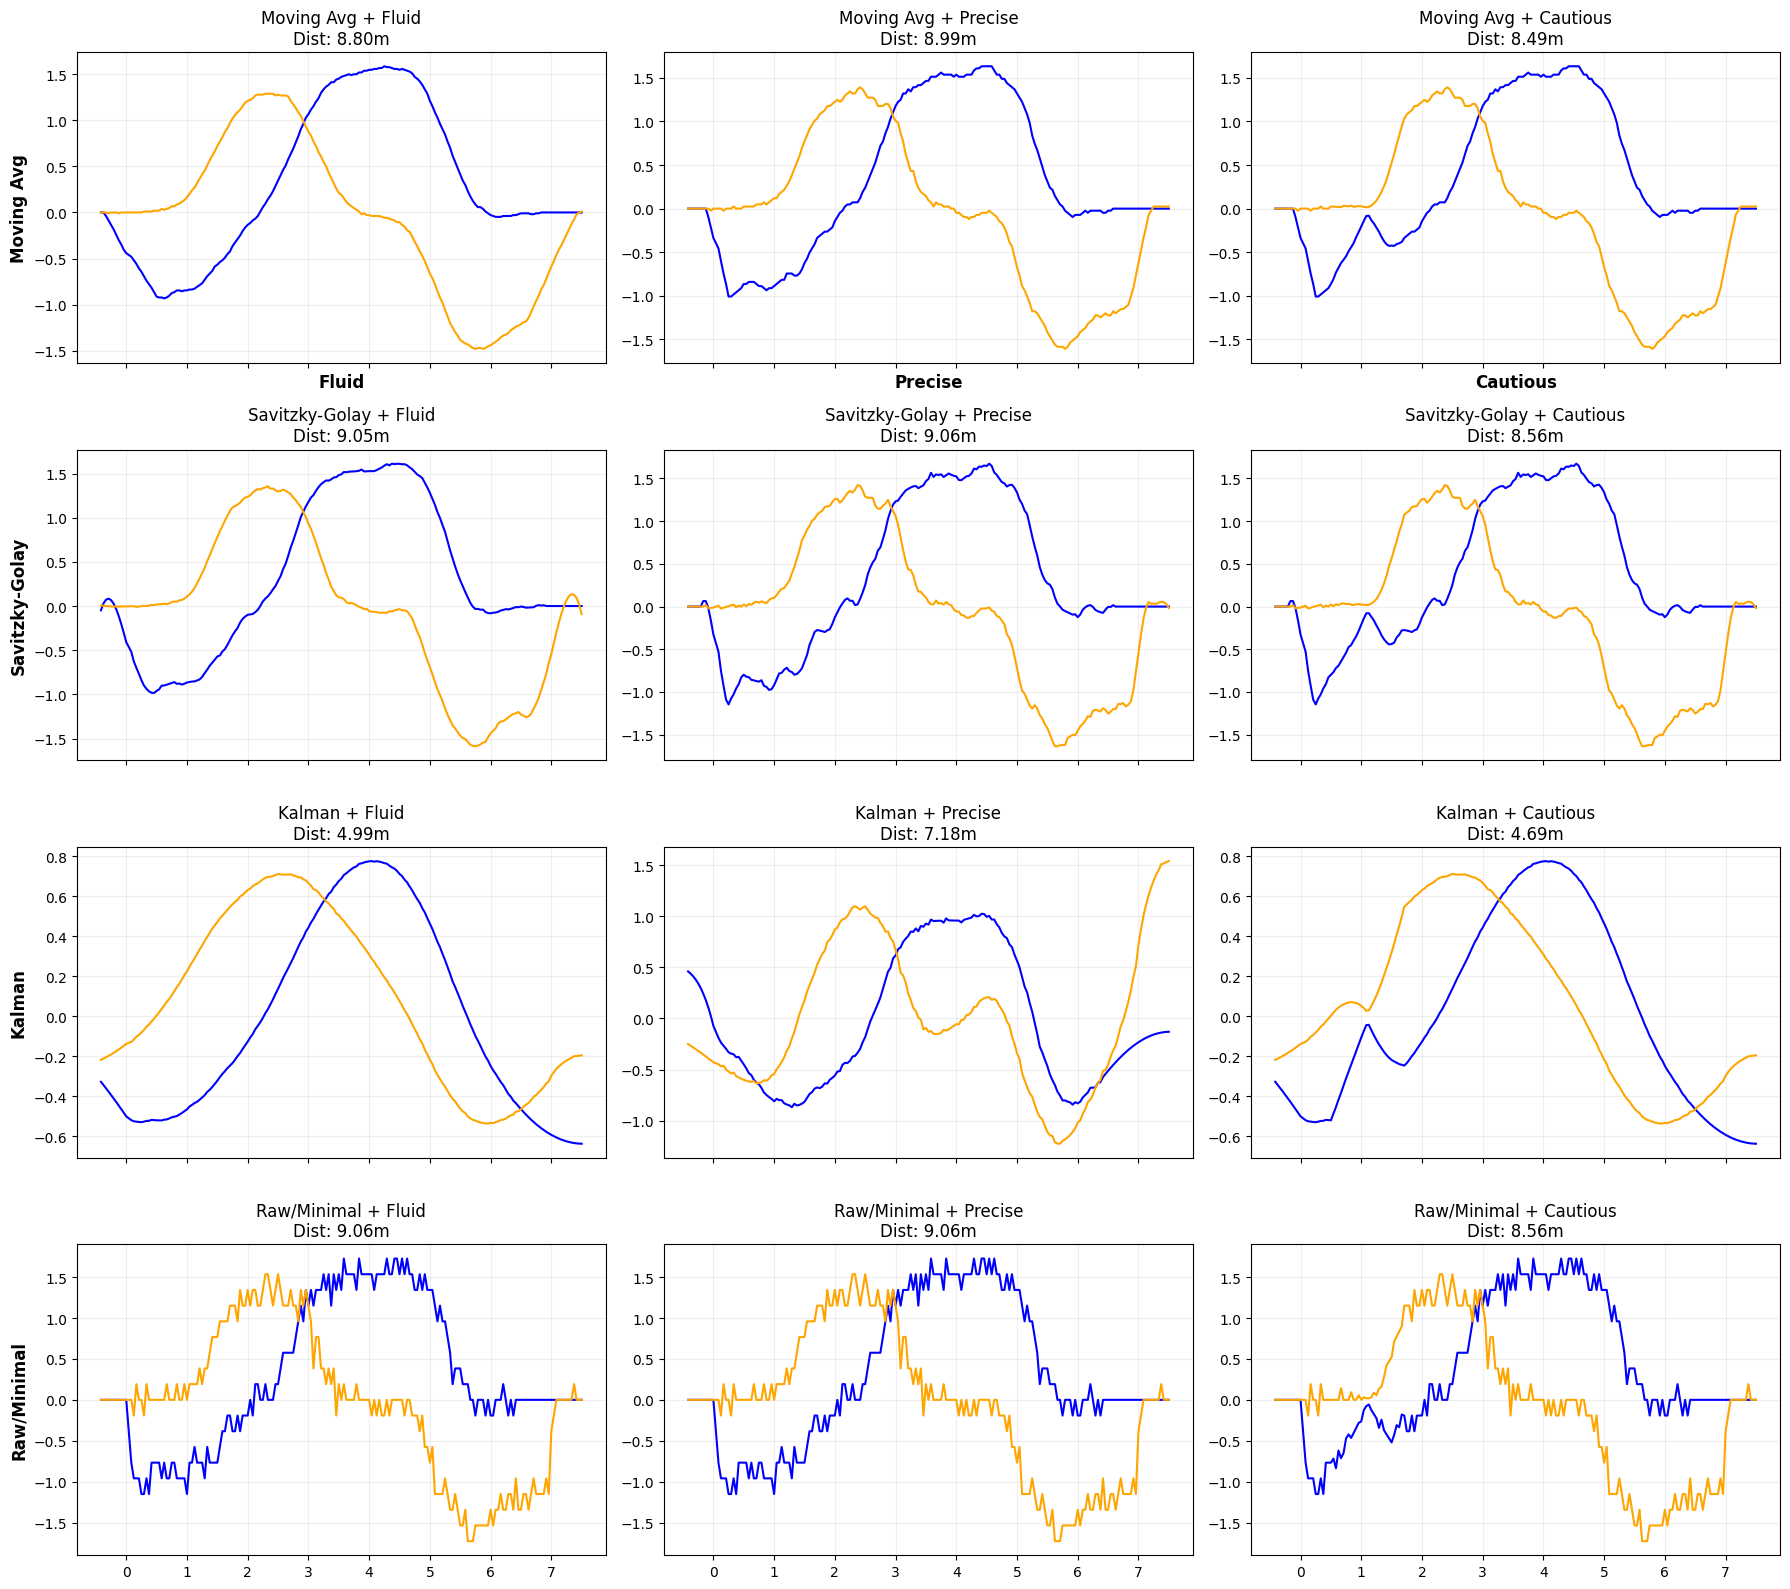

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.integrate import trapezoid
import cv2

# --- 1. Foundation & Zero-Anchor Setup ---
# Creating the standing start buffer
time_zeros = np.linspace(-10/fps, -1/fps, 10)
velocity_zeros = np.zeros(10)
time_ext = np.concatenate([time_zeros, movement[:, 0]])
vx_raw = np.concatenate([velocity_zeros, movement[:, 1]])
vy_raw = np.concatenate([velocity_zeros, movement[:, 2]])

def get_pivot_mask(data, intensity=0.1):
    total_v = np.sqrt(vx_raw**2 + vy_raw**2)
    # Finding the 'dip' in speed at the corner
    mid = np.argmin(total_v[20:-20]) + 20
    mask = np.ones_like(data)
    window = 15
    mask[mid-window:mid+window] = np.linspace(1, intensity, window).tolist() + np.linspace(intensity, 1, window).tolist()
    return mask

def run_kalman_custom(data, p_noise):
    dt = 1.0/fps
    kf = cv2.KalmanFilter(3, 1, 0)
    kf.transitionMatrix = np.array([[1, dt, 0.5*dt**2],
                                    [0, 1, dt],
                                    [0, 0, 1]], np.float32)
    kf.measurementMatrix = np.array([[1, 0, 0]], np.float32)
    kf.processNoiseCov = np.eye(3, dtype=np.float32) * p_noise
    kf.measurementNoiseCov = np.array([[0.1]], np.float32)

    # Corrected Kalman Loop to avoid the Truth Value error
    res_fwd = []
    for z in data:
        kf.correct(np.array([[np.float32(z)]]))
        prediction = kf.predict()
        res_fwd.append(kf.statePost[1, 0]) # Extracting Velocity state

    # Resetting for Backward pass
    kf.statePost = np.array([[data[-1]], [0], [0]], np.float32)
    res_bwd = []
    for z in data[::-1]:
        kf.correct(np.array([[np.float32(z)]]))
        prediction = kf.predict()
        res_bwd.append(kf.statePost[1, 0])

    return (np.array(res_fwd) + np.array(res_bwd[::-1])) / 2

# --- 2. Generation Loop ---
filter_types = ['Moving Avg', 'Savitzky-Golay', 'Kalman', 'Raw/Minimal']
methods = ['Fluid', 'Precise', 'Cautious']

fig, axes = plt.subplots(4, 3, figsize=(18, 16), sharex=True)

for r, f_name in enumerate(filter_types):
    for c, m_name in enumerate(methods):
        # A. Filtering Logic
        if f_name == 'Moving Avg':
            win = 20 if m_name == 'Fluid' else 8
            vx = np.convolve(vx_raw, np.ones(win)/win, mode='same')
            vy = np.convolve(vy_raw, np.ones(win)/win, mode='same')
        elif f_name == 'Savitzky-Golay':
            win = 25 if m_name == 'Fluid' else 11
            vx = savgol_filter(vx_raw, win, 3)
            vy = savgol_filter(vy_raw, win, 3)
        elif f_name == 'Kalman':
            noise = 1e-3 if m_name == 'Precise' else 1e-5
            vx = run_kalman_custom(vx_raw, noise)
            vy = run_kalman_custom(vy_raw, noise)
        else: # Raw/Minimal
            vx, vy = vx_raw, vy_raw

        # B. Turn Personality Logic
        if m_name == 'Cautious':
            mask = get_pivot_mask(vx)
            vx, vy = vx * mask, vy * mask

        # C. Plotting & Distance Audit
        ax = axes[r, c]
        dist = trapezoid(np.sqrt(vx**2 + vy**2), dx=1/fps)
        ax.plot(time_ext, vx, color='blue', label='Vx')
        ax.plot(time_ext, vy, color='orange', label='Vy')
        ax.set_title(f"{f_name} + {m_name}\nDist: {dist:.2f}m")
        if r == 0: ax.set_xlabel(m_name, fontsize=12, fontweight='bold')
        if c == 0: ax.set_ylabel(f_name, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from scipy.signal import savgol_filter
import cv2

def create_kinematic_plan(vx_raw, vy_raw, fps=24.0, filter_type='Savitzky-Golay', method='Fluid'):
    # 1. Zero-Anchor (10 frames of standing still)
    vx_anchored = np.concatenate([np.zeros(10), vx_raw])
    vy_anchored = np.concatenate([np.zeros(10), vy_raw])

    # 2. Apply Filtering Philosophy
    if filter_type == 'Savitzky-Golay':
        # Fluid uses a large window (35) to round corners; Precise uses a tight window (11)
        win = 25 if method == 'Fluid' else 11
        vx = savgol_filter(vx_anchored, win, 3)
        vy = savgol_filter(vy_anchored, win, 3)

    elif filter_type == 'Moving Avg':
        # Fluid uses heavy averaging; Precise uses minimal averaging
        win = 20 if method == 'Fluid' else 5
        vx = np.convolve(vx_anchored, np.ones(win)/win, mode='same')
        vy = np.convolve(vy_anchored, np.ones(win)/win, mode='same')

    elif filter_type == 'Kalman':
        # Precise uses low process noise to follow pixels; Fluid uses high noise for inertia
        noise = 1e-5 if method == 'Fluid' else 1e-3

        def simple_kalman(data, q_noise):
            dt = 1.0/fps
            kf = cv2.KalmanFilter(3, 1, 0)
            kf.transitionMatrix = np.array([[1, dt, 0.5*dt**2], [0, 1, dt], [0, 0, 1]], np.float32)
            kf.measurementMatrix = np.array([[1, 0, 0]], np.float32)
            kf.processNoiseCov = np.eye(3, dtype=np.float32) * q_noise
            kf.measurementNoiseCov = np.array([[0.1]], np.float32)

            res = []
            for z in data:
                kf.correct(np.array([[np.float32(z)]]))
                kf.predict()
                res.append(kf.statePost[1, 0])
            return np.array(res)

        vx = simple_kalman(vx_anchored, noise)
        vy = simple_kalman(vy_anchored, noise)

    else: # 'Raw' or anything else
        vx, vy = vx_anchored, vy_anchored

    # 3. Apply Turn Personality (Cautious Pivot)
    if method == 'Cautious':
        total_v = np.sqrt(vx**2 + vy**2)
        # Find the turning point by searching for the minimum speed in the middle of the run
        mid = np.argmin(total_v[20:-20]) + 20
        mask = np.ones_like(vx)
        mask[mid-10:mid+10] = 0.1 # Force a near-stop to simulate a robotic pivot
        vx, vy = vx * mask, vy * mask

    # 4. Final Packaging
    time_col = np.linspace(0, (len(vx) - 1) / fps, len(vx))
    return np.column_stack((time_col, vx, vy))

In [ ]:
import numpy as np
from scipy.signal import savgol_filter

def create_kinematic_plan(vx_raw, vy_raw, fps=24.0, filter_type='Savitzky-Golay', method='Fluid'):
    # 1. Zero-Anchor (We still need this to give the filter a "landing pad")
    # This acts as the natural "stop" without forcing it
    vx_anchored = np.concatenate([np.zeros(10), vx_raw])
    vy_anchored = np.concatenate([np.zeros(10), vy_raw])

    # 2. Apply the "Goldilocks" Window (25)
    # We use 25 because your plot proved it's the best balance
    if filter_type == 'Savitzky-Golay':
        win = 25
        vx = savgol_filter(vx_anchored, win, 3)
        vy = savgol_filter(vy_anchored, win, 3)

    # ... [Keep other filter options if needed] ...

    # 3. NO HARD STOPS HERE
    # We removed the lines that force vx[:10] = 0

    # 4. Final Packaging
    time_col = np.linspace(0, (len(vx) - 1) / fps, len(vx))
    return np.column_stack((time_col, vx, vy))

In [ ]:
# 1. REPLACE THESE with your actual speed variable names
my_actual_vx = vx_raw  # <--- Change 'v_x' to your actual variable name
my_actual_vy = vy_raw  # <--- Change 'v_y' to your actual variable name

# 2. Now run the create_kinematic_plan function
my_plan = create_kinematic_plan(my_actual_vx, my_actual_vy,
                                filter_type='Savitzky-Golay',
                                method='Fluid')

# 3. Feed it into your original visualizer function
process_video_with_auto_track(
    input_video_path='/content/Robot_Navigates_White_Maze.mp4',
    output_video_path='test_result.mp4',
    kinematic_data=my_plan,
    scale_factor=125
)

Robot detected at start position: (588, 265)
Finished. Saved to test_result.mp4


In [ ]:
from IPython.display import HTML
from base64 import b64encode

def display_webm(path):
    # Ensure we are looking for the .webm version
    webm_path = path.replace('.mp4', '.webm')
    video_file = open(webm_path, "rb").read()
    video_url = f"data:video/webm;base64,{b64encode(video_file).decode()}"
    return HTML(f"""
    <video width="800" controls>
          <source src="{video_url}" type="video/webm">
    </video>
    """)

# Call this after your processing is done
display_webm('/content/test_result.webm')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# 1. Setup Data (Using your actual variables)
# Ensure v_x and v_y are defined from your previous steps!
vx_anchored = np.concatenate([np.zeros(10), vx_raw])
vy_anchored = np.concatenate([np.zeros(10), vy_raw])
time_col = np.linspace(0, len(vx_anchored)/24.0, len(vx_anchored))

# 2. Define the Candidates
windows = [11, 25, 35]
colors = ['red', 'green', 'blue']
labels = ['Precise (11)', 'Compromise (25)', 'Fluid (35)']

plt.figure(figsize=(12, 6))

for win, col, lab in zip(windows, colors, labels):
    # Apply Filter
    filt_vx = savgol_filter(vx_anchored, win, 3)
    filt_vy = savgol_filter(vy_anchored, win, 3)

    # Calculate Total Speed for clearer comparison
    speed = np.sqrt(filt_vx**2 + filt_vy**2)

    # Plot
    plt.plot(time_col, speed, color=col, label=f"{lab} - Win: {win}", linewidth=2, alpha=0.8)

# 3. Formatting
plt.title("Tuning the Window Size: Finding the Sweet Spot")
plt.xlabel("Time (s)")
plt.ylabel("Total Speed (m/s)")
plt.axhline(0, color='black', linewidth=1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# --- 1. SETUP THE NATURAL PLAN (Window 25, No Hard Stops) ---
# Ensure v_x and v_y are your actual raw speed variables
vx_raw = np.array(vx_raw)
vy_raw = np.array(vy_raw)

# Zero-Anchor (Standard prep)
vx_anchored = np.concatenate([np.zeros(10), vx_raw])
vy_anchored = np.concatenate([np.zeros(10), vy_raw])

# Apply Filter (Window 25)
win = 25
vx_natural = savgol_filter(vx_anchored, win, 3)
vy_natural = savgol_filter(vy_anchored, win, 3)

# Create Time Axis
time_col = np.linspace(0, len(vx_natural)/24.0, len(vx_natural))

# --- 2. PLOT THE "DRIFT CHECK" ---
plt.figure(figsize=(12, 6))

# Plot Total Speed
speed_raw = np.sqrt(vx_anchored**2 + vy_anchored**2)
speed_natural = np.sqrt(vx_natural**2 + vy_natural**2)

plt.plot(time_col, speed_raw, color='lightgray', label='Raw Input', linewidth=1)
plt.plot(time_col, speed_natural, color='green', label='Natural Filter (Win 25)', linewidth=2)

# Zoom in on the Danger Zones (Start and Stop)
plt.axhline(0, color='black', linewidth=1)
plt.axvspan(0, 0.5, color='red', alpha=0.1, label='Start Drift Zone')
plt.axvspan(time_col[-1]-0.5, time_col[-1], color='red', alpha=0.1)

plt.title("The 'Natural' Filter Test: Checking for Drift")
plt.xlabel("Time (s)")
plt.ylabel("Speed (m/s)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# --- 1. SETUP DATA ---
# (Ensure v_x and v_y are your actual raw speed variables)
vx_raw = np.array(vx_raw)
vy_raw = np.array(vy_raw)

# Zero-Anchor Prep
vx_anchored = np.concatenate([np.zeros(10), vx_raw])
vy_anchored = np.concatenate([np.zeros(10), vy_raw])
time_col = np.linspace(0, len(vx_anchored)/24.0, len(vx_anchored))

# --- 2. COMPUTE FILTERS ---
win = 25

# A. Natural (No Hard Stop)
vx_natural = savgol_filter(vx_anchored, win, 3)
vy_natural = savgol_filter(vy_anchored, win, 3)

# B. With Hard Stop (For Comparison)
vx_stopped = vx_natural.copy()
vy_stopped = vy_natural.copy()
vx_stopped[:10] = 0; vx_stopped[-10:] = 0
vy_stopped[:10] = 0; vy_stopped[-10:] = 0

# --- 3. PLOT X AND Y SEPARATELY ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# PLOT X VELOCITY
ax1.plot(time_col, vx_anchored, color='lightgray', label='Raw Input', linewidth=1)
ax1.plot(time_col, vx_natural, color='blue', label='Natural (Win 25)', linewidth=2)
ax1.plot(time_col, vx_stopped, color='cyan', linestyle='--', label='Hard Stop Reference', linewidth=2)
ax1.axhline(0, color='black', linewidth=1)
ax1.set_ylabel("Velocity X (m/s)", fontsize=12)
ax1.set_title("X-Direction: Natural vs Hard Stop", fontsize=14)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# PLOT Y VELOCITY
ax2.plot(time_col, vy_anchored, color='lightgray', label='Raw Input', linewidth=1)
ax2.plot(time_col, vy_natural, color='orange', label='Natural (Win 25)', linewidth=2)
ax2.plot(time_col, vy_stopped, color='red', linestyle='--', label='Hard Stop Reference', linewidth=2)
ax2.axhline(0, color='black', linewidth=1)
ax2.set_ylabel("Velocity Y (m/s)", fontsize=12)
ax2.set_xlabel("Time (s)", fontsize=12)
ax2.set_title("Y-Direction: Natural vs Hard Stop", fontsize=14)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()